#  Analyze Datasets

# ***Questions***


* Why MinMaxScaler sometimes work better in Clustering?

  > Clustering algorithms — especially **distance-based** ones like K-Means, DBSCAN, and Hierarchical Clustering — are sensitive to the scale of features.

  > MinMaxScaler can work better for clustering when:
    * Features are on different scales.
    * You care about bounded values and relative proportions.
    * You want to ensure **equal contribution** from all features to distance calculations.

* When should i use MinMaxScaler and StandardScaler?

>| Feature                           | `MinMaxScaler`            | `StandardScaler`          |
  | --------------------------------- | ------------------------- | ------------------------- |
  | Output range                      | \[0, 1] (or custom range) | Mean = 0, Std = 1         |
  | Preserves shape                   | ✅ Yes                     | ❌ Changes shape (z-score) |
  | Affected by outliers              | ✅ Yes                     | ✅ Yes (sometimes more)    |
  | Use for distance-based models     | ✅ Yes                     | ❌ Not ideal               |
  | Use for normally distributed data | ❌ Not ideal               | ✅ Yes                     |

# ***Analyzing sklearn Datasets***

# **Imports**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from tabulate import tabulate

plt.style.use("Solarize_Light2")

In [2]:
from sklearn.datasets import load_breast_cancer, load_iris

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from imblearn.over_sampling import RandomOverSampler

# **Global Functions**

In [3]:
def normalization(data, model):
  norm_data= pd.DataFrame(data=model.transform(data), columns=data.columns)

  return norm_data

In [4]:
from scipy.stats import mode

def remap_clusters(true_labels, predicted_clusters):
    labels = np.zeros_like(predicted_clusters)
    for cluster in np.unique(predicted_clusters):
        mask = (predicted_clusters == cluster)
        labels[mask] = mode(true_labels[mask], keepdims=True)[0]
    return labels

# **Cluster Metrics**

In unsupervised learning, you don't have y_train, y_val, but you still often want to:

(For production it's better to split to train, val and test)

* **Evaluate cluster stability/generalization**

* **Tune parameters** (e.g., number of clusters) using only part of the data

In [5]:
def calculate_accuracy(confusion_matrix) -> float:
    """
    Calculate accuracy from the confusion matrix.
    Accuracy is the ratio of correct predictions to total samples.

    Args:
    confusion_matrix (np.array): The confusion matrix.

    Returns:
    float: Accuracy value.
    """
    # Total correct predictions are the sum of the diagonal elements
    correct_predictions = np.trace(confusion_matrix)

    # Total samples is the sum of all elements in the confusion matrix
    total_samples = np.sum(confusion_matrix)

    # Calculate accuracy
    accuracy = correct_predictions / total_samples
    return accuracy

In [6]:
def cal_f1_score(confusion_mat):
    prf1 = []
    cm = np.array(confusion_mat)
    for i in range(cm.shape[0]):
        row_sum = np.sum(cm[i, :])
        col_sum = np.sum(cm[:, i])

        if row_sum == 0 or col_sum == 0:
            prf1.append(np.array([0, 0, 0]))
            continue

        recall = cm[i, i] / row_sum
        precision = cm[i, i] / col_sum

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = (2 * recall * precision) / (precision + recall)

        prf1.append(np.array([precision, recall, f1]))

    return np.array(prf1)

In [7]:
def metrics_table(method_name, prf_array, accuracy, w_precision, w_recall, w_f1):
    rows = []

    for i, (p, r, f1) in enumerate(prf_array):
        rows.append([method_name, i, f"{p:.2f}", f"{r:.2f}", f"{f1:.2f}", ""])

    # Summary row with weighted metrics
    rows.append([
        method_name, "Overall",
        f"{w_precision:.3f}", f"{w_recall:.3f}", f"{w_f1:.3f}", f"{accuracy:.2%}"
    ])

    print(tabulate(
        rows,
        headers=["Method", "Cluster", "Precision", "Recall", "F1 Score", "Accuracy"],
        tablefmt="grid"
    ))


In [8]:
def calculate_metrics(cm):
    # Accuracy
    acc_kmeans = calculate_accuracy(cm)

    # Precision, recall, F1
    prf_kmeans = np.array(cal_f1_score(cm))

    # Weighted Precision, recall, F1
    weights_k = np.sum(cm, axis=1)

    # Weighted Precision, Recall, F1 for K-Means
    wp_k = np.sum(prf_kmeans[:, 0] * weights_k) / np.sum(weights_k)
    wr_k = np.sum(prf_kmeans[:, 1] * weights_k) / np.sum(weights_k)
    wf1_k = np.sum(prf_kmeans[:, 2] * weights_k) / np.sum(weights_k)

    metrics_table("K-Means", prf_kmeans, acc_kmeans, wp_k, wr_k, wf1_k)

# .
# **Breast Cancer**
* Diagnosis (M = malignant = 0, B = benign = 1)
* Analyzing **binary** data involves examining the frequency of each category and understanding relationships with other variables.



## 0 Load


In [9]:
bc_x, bc_y = load_breast_cancer(return_X_y=True, as_frame=True)

In [10]:
bc_df = bc_x.copy()
bc_df["is benign"] = bc_y.astype(np.int8).copy()
bc_nominal_label = bc_df["is benign"].map({0: "malignant", 1: "benign"}).rename("label").copy()

In [11]:
bc_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


## 1 Exploratory Data Analysis (EDA)

### info

In [ ]:
bc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### describe

In [ ]:
bc_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,is benign
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### values count

In [ ]:
bc_df["is benign"].value_counts()

,count
is benign,
1,357
0,212


### correlation

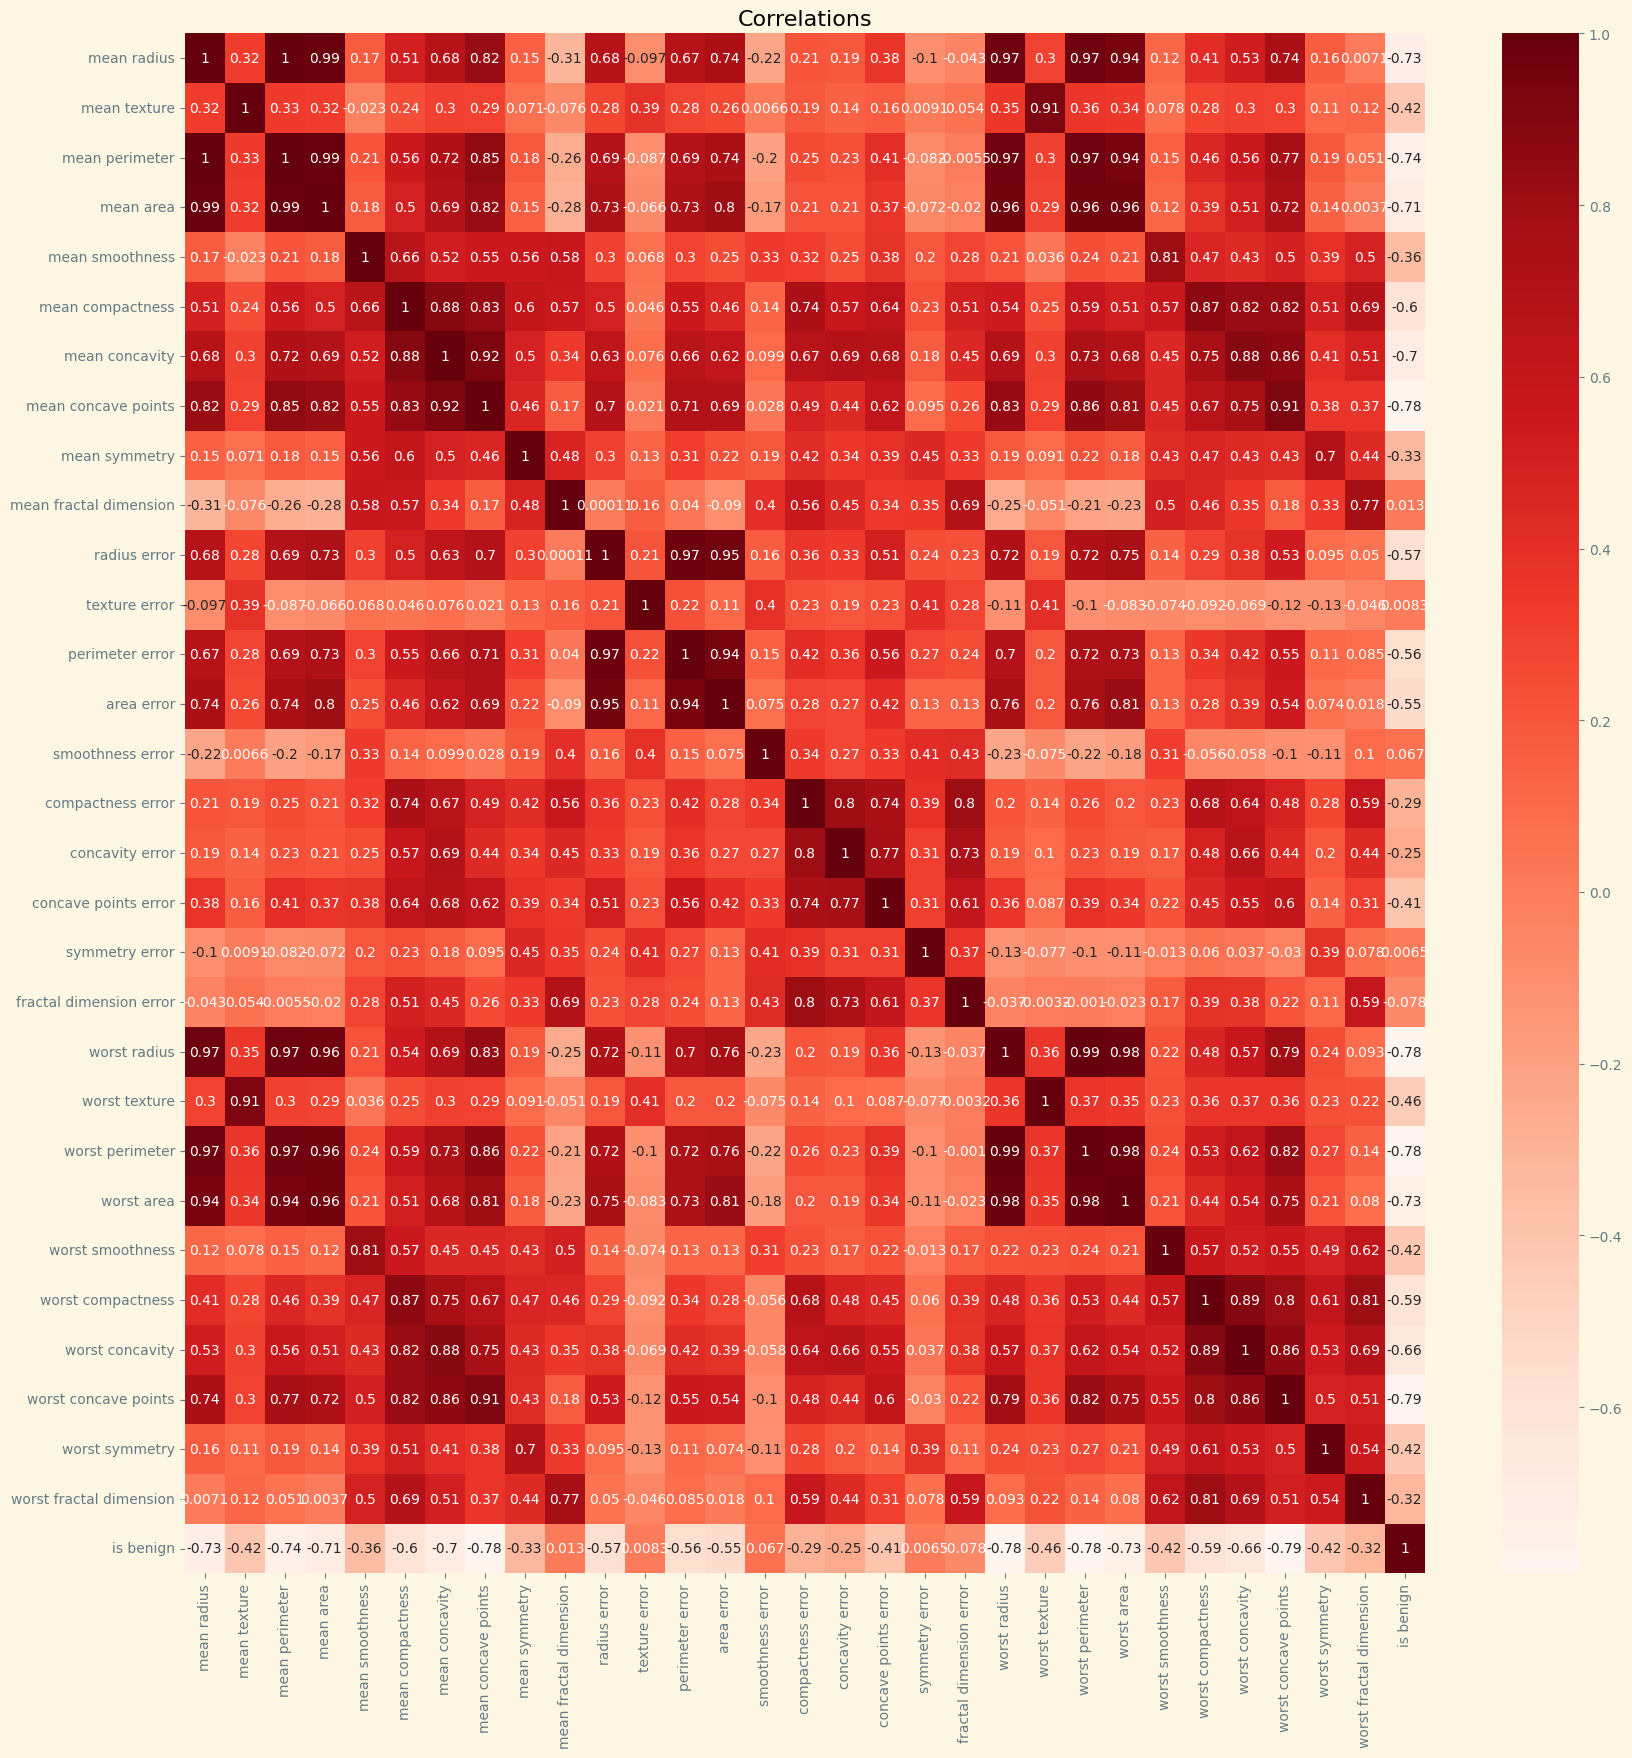

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(bc_df.corr(), annot=True, cmap="Reds", ax=ax)

plt.title("Correlations")
plt.show()

### histogram

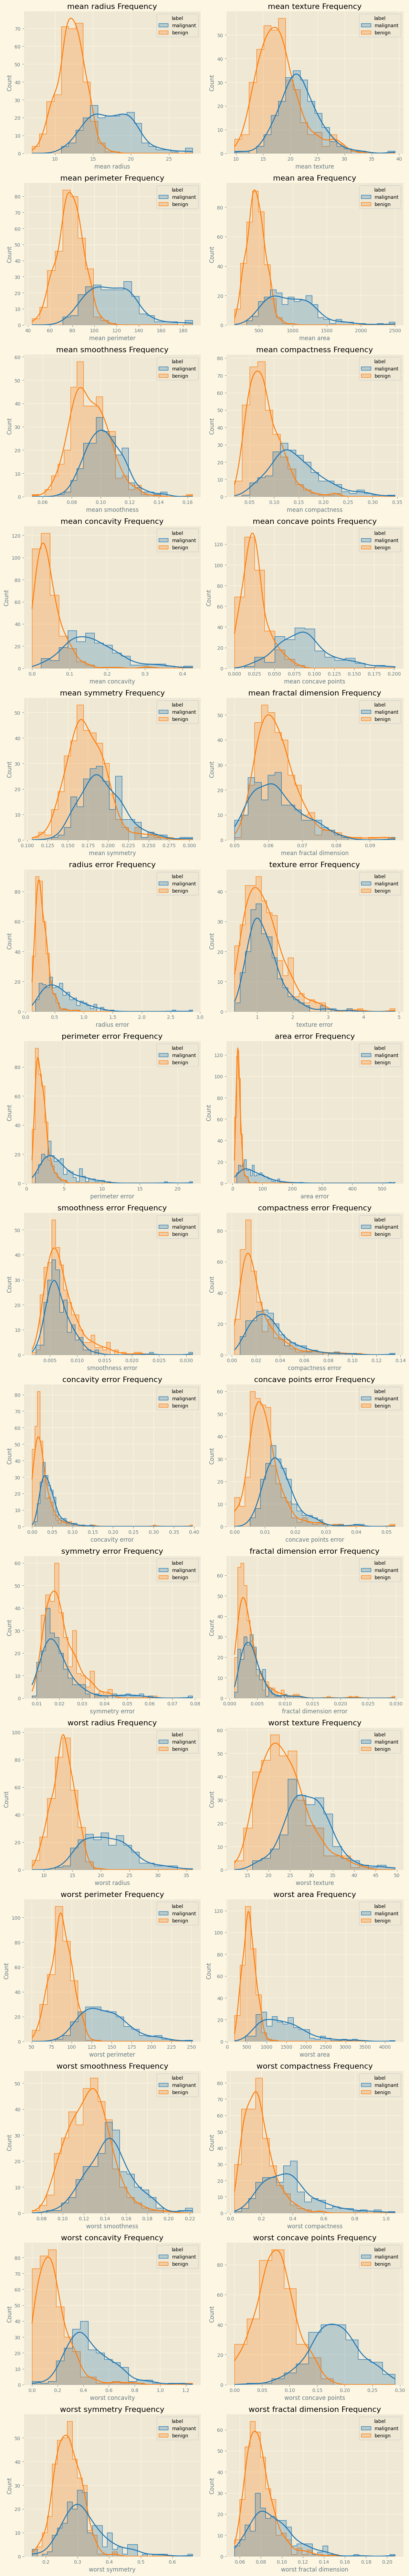

In [ ]:
cols = bc_df.columns.drop('is benign')  # Optional: exclude target column if needed
num_cols = len(cols)
cols_per_row = 2
num_rows = (num_cols + 1) // cols_per_row

plt.figure(figsize=(12, num_rows * 5))

for idx, col_name in enumerate(cols, start=1):
    plt.subplot(num_rows, cols_per_row, idx)
    sns.histplot(data=bc_df, x=col_name, hue=bc_nominal_label, palette="tab10", element="step", kde=True)
    plt.title(f"{col_name} Frequency")

plt.tight_layout()
plt.show()

# 0, 2, 3, 6, 7, 10, 12, 13, 20, 22, 23, 27

### pie chart

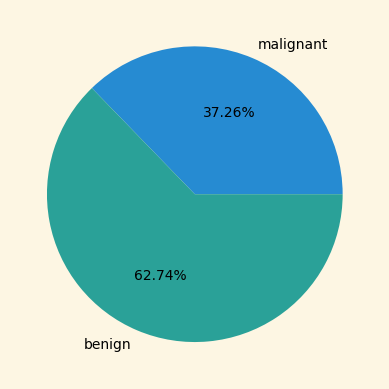

In [ ]:
plt.pie(x=bc_nominal_label.value_counts(sort=False), autopct="%.2f%%", labels=bc_nominal_label.unique())
plt.show()

### scatter plot

#### vs is benign

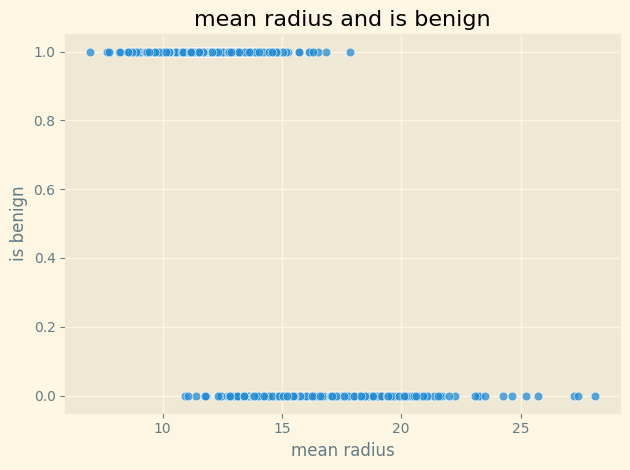

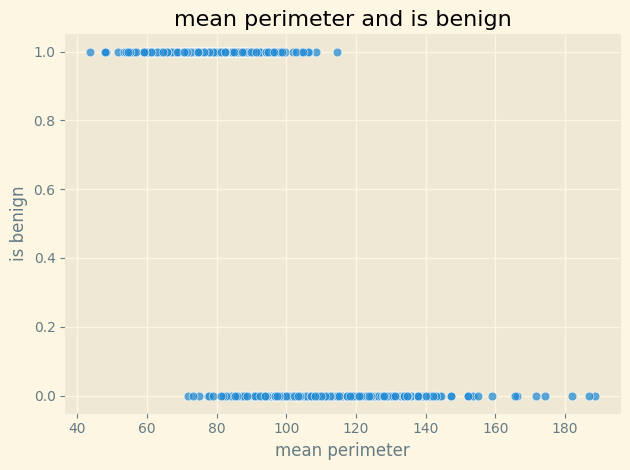

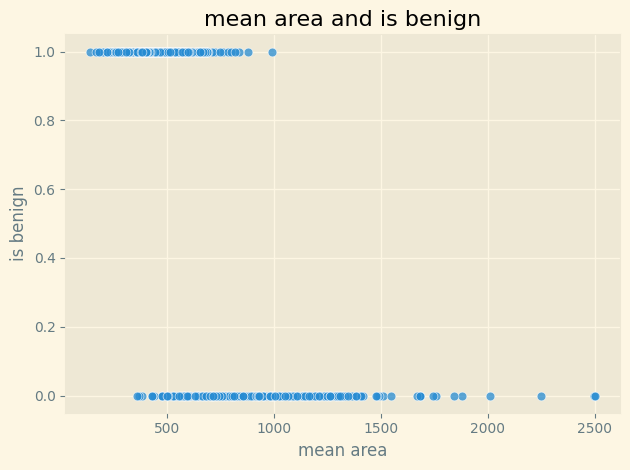

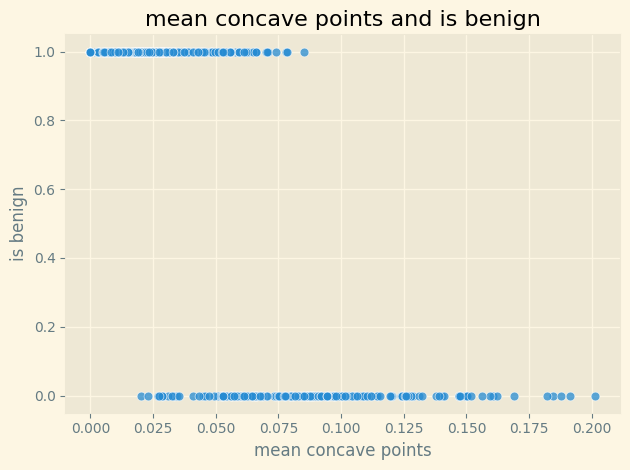

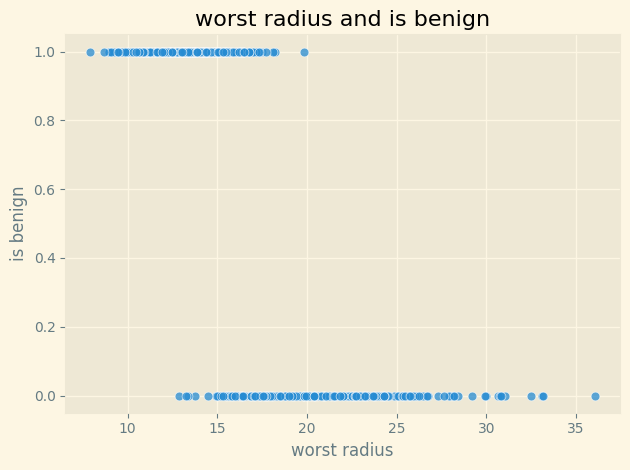

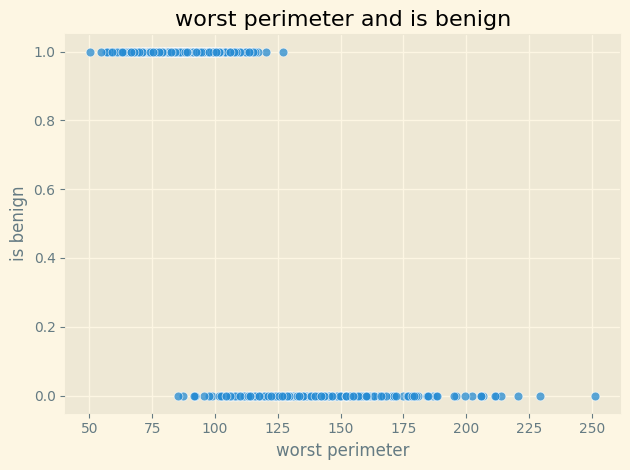

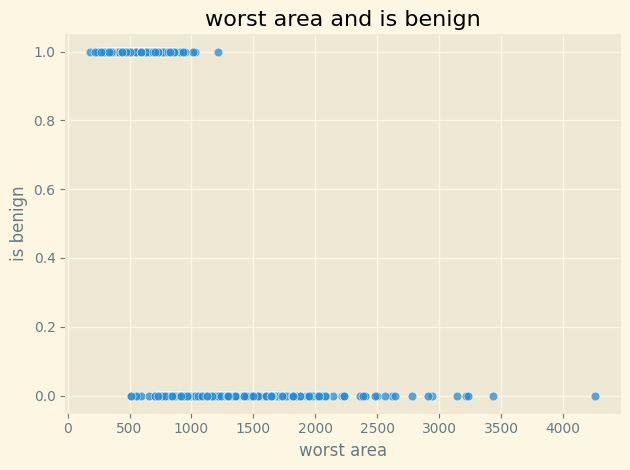

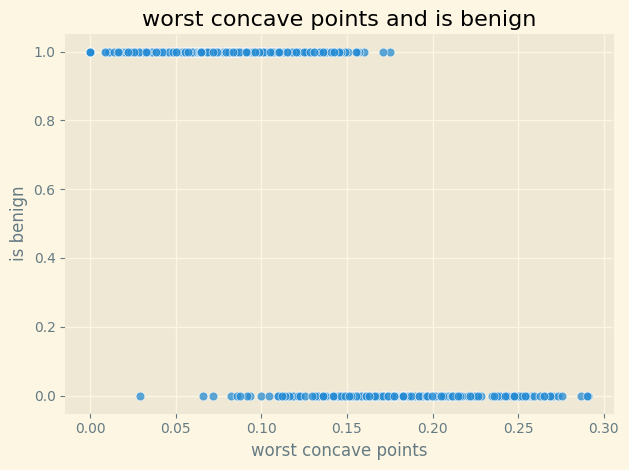

In [ ]:
col_names = bc_df.columns[[0, 2, 3, 7, 20, 22, 23, 27]]


for col_name in col_names:
    sns.scatterplot(data=bc_df, x=col_name, y="is benign", s=40, alpha=0.75)
    plt.title(f"{col_name} and is benign")
    plt.tight_layout()
    plt.show()

#### pairs

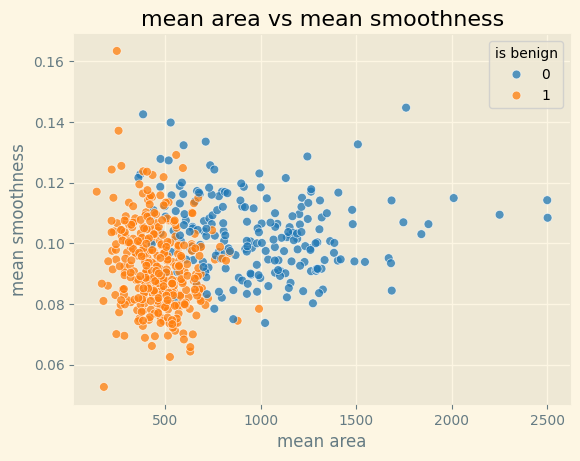

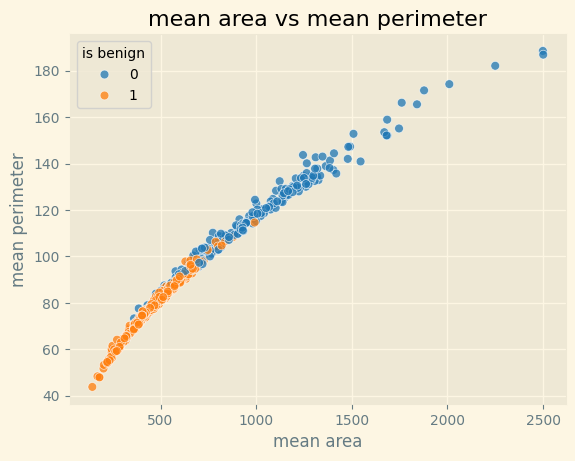

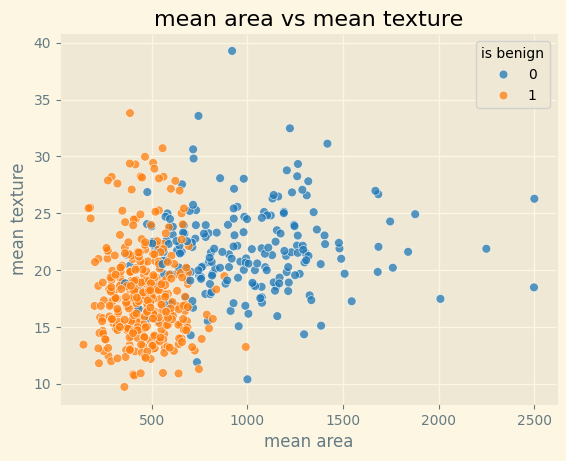

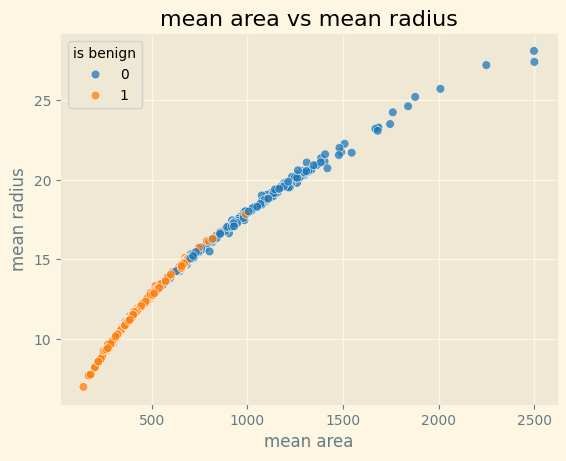

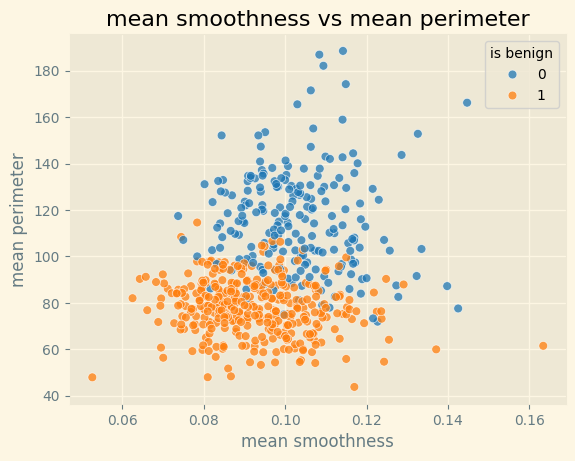

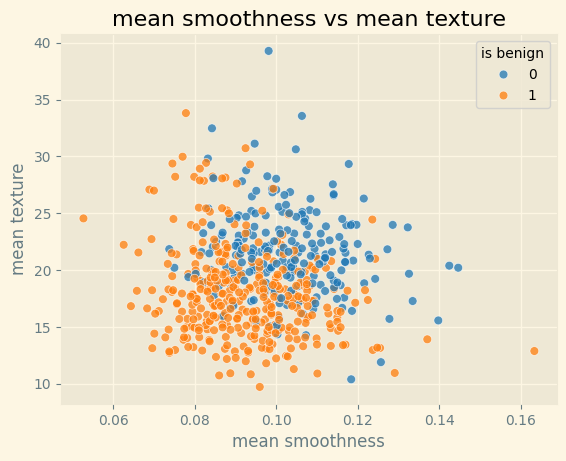

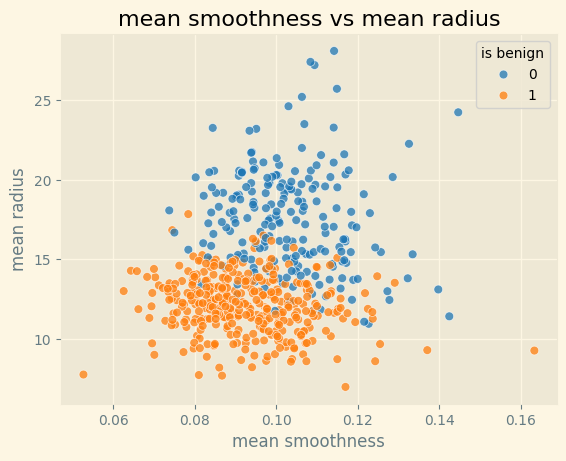

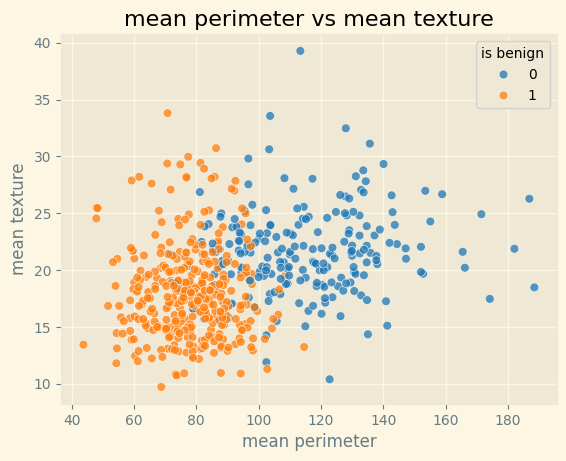

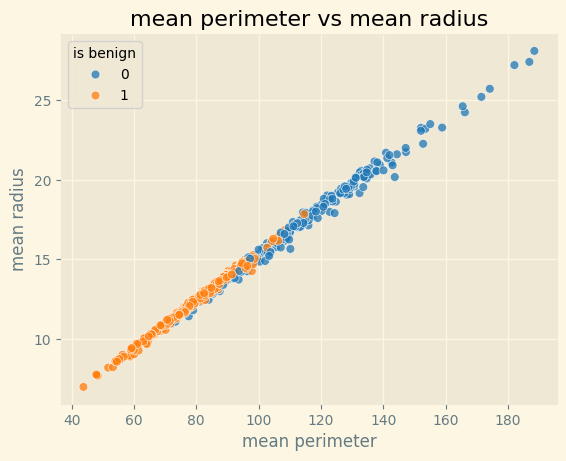

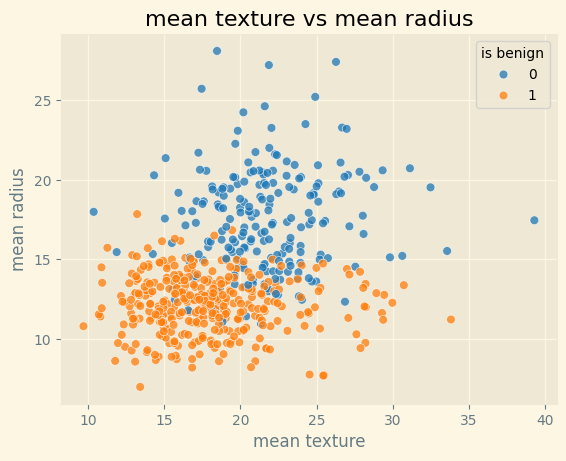

In [ ]:
col_names = ["mean area", "mean smoothness", "mean perimeter", "mean texture", "mean radius"]

for i in range(len(col_names)):
    for j in range(i + 1, len(col_names)):
          sns.scatterplot(data=bc_df, x=col_names[i], y=col_names[j], hue="is benign", palette="tab10", s=40, alpha=0.75)
          plt.xlabel(col_names[i])
          plt.ylabel(col_names[j])
          plt.title(f"{col_names[i]} vs {col_names[j]}")
          plt.show()

## 2 Normalization and Split Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(bc_df.drop(["is benign"], axis=1), bc_df["is benign"], test_size=0.33, random_state=42)

In [13]:
model = MinMaxScaler().fit(X_train)
X_train = normalization(X_train, model)
X_test = normalization(X_test, model)

### balance data

In [14]:
ros = RandomOverSampler()
X_train, y_train = ros.fit_resample(X_train, y_train)

In [15]:
y_train.value_counts()

,count
is benign,
0,236
1,236


## 3 Apply ML Models

### Logistic regression
Logistic (logit link) or log-risk/log-binomial (log link) regression are the most common GLM to fit to a binary outcome.

#### all columns

In [16]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

report = classification_report(y_test, y_pred_log, digits=2)
print(report)

print(classification_report(y_train, log_model.predict(X_train), digits=2)) # check for overfitting

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.99      0.98      0.98       121

    accuracy                           0.98       188
   macro avg       0.97      0.98      0.98       188
weighted avg       0.98      0.98      0.98       188

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       236
           1       0.96      0.99      0.97       236

    accuracy                           0.97       472
   macro avg       0.98      0.97      0.97       472
weighted avg       0.98      0.97      0.97       472



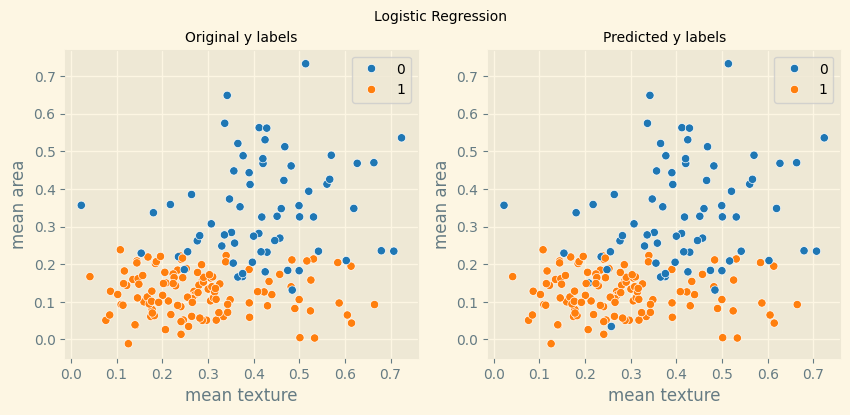

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plt.suptitle("Logistic Regression", fontsize=10)

sns.scatterplot(data=X_test, x="mean texture", y="mean area", hue=np.array(y_test), ax=axes[0], palette="tab10")
axes[0].set_title("Original y labels", fontsize=10)

sns.scatterplot(data=X_test, x="mean texture", y="mean area", hue=y_pred_log, ax=axes[1], palette="tab10")
axes[1].set_title("Predicted y labels", fontsize=10)

plt.show()

#### selected columns

In [18]:
log_model = LogisticRegression()
log_model.fit(X_train.iloc[:, [0, 2, 3, 7, 20, 22, 23, 27]], y_train)

y_pred = log_model.predict(X_test.iloc[:, [0, 2, 3, 7, 20, 22, 23, 27]])
y_true = y_test

report = classification_report(y_true, y_pred, digits=2)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        67
           1       0.97      0.96      0.97       121

    accuracy                           0.96       188
   macro avg       0.95      0.96      0.95       188
weighted avg       0.96      0.96      0.96       188



### KNN classification

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

report = classification_report(y_true=y_test, y_pred=y_pred_knn)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        67
           1       0.97      0.96      0.97       121

    accuracy                           0.96       188
   macro avg       0.95      0.96      0.95       188
weighted avg       0.96      0.96      0.96       188



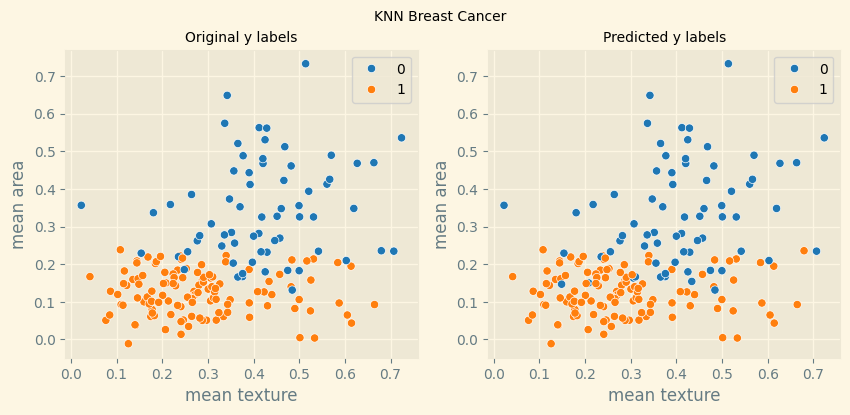

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plt.suptitle("KNN Breast Cancer", fontsize=10)

sns.scatterplot(data=X_test, x="mean texture", y="mean area", hue=np.array(y_test), ax=axes[0], palette="tab10")
axes[0].set_title("Original y labels", fontsize=10)

sns.scatterplot(data=X_test, x="mean texture", y="mean area", hue=y_pred_knn, ax=axes[1], palette="tab10")
axes[1].set_title("Predicted y labels", fontsize=10)

plt.show()

### K-Means Clustering

In [21]:
kmeans = KMeans(n_clusters=2, n_init='auto')
y_pred_k_means = kmeans.fit_predict(X_train)

#### confusing matrix

In [22]:
y_pred_k_means_remapped = remap_clusters(y_train, y_pred_k_means)
cm_k_means = confusion_matrix(y_train, y_pred_k_means_remapped)

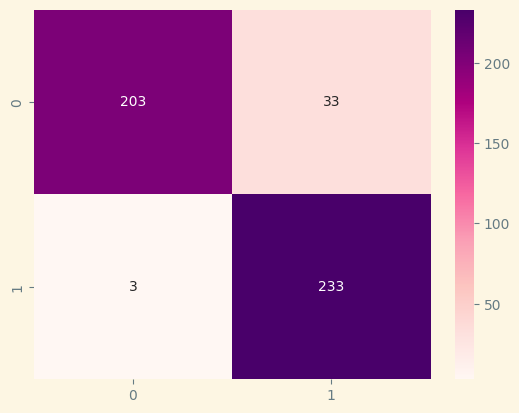

+----------+-----------+-------------+----------+------------+------------+
| Method   | Cluster   |   Precision |   Recall |   F1 Score | Accuracy   |
+==========+===========+=============+==========+============+============+
| K-Means  | 0         |       0.99  |    0.86  |      0.92  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 1         |       0.88  |    0.99  |      0.93  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | Overall   |       0.931 |    0.924 |      0.923 | 92.37%     |
+----------+-----------+-------------+----------+------------+------------+


In [23]:
sns.heatmap(cm_k_means, annot=True, fmt='d', cmap='RdPu')
plt.show()

calculate_metrics(cm=cm_k_means)

#### plotting

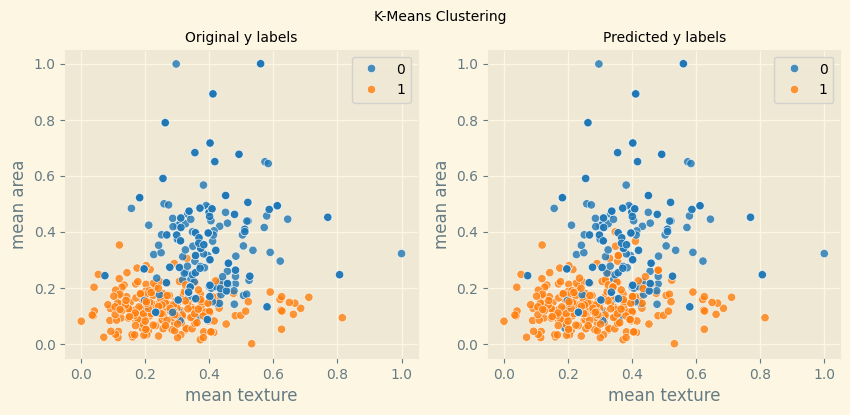

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4)) # dpi here

plt.suptitle("K-Means Clustering", fontsize=10)

sns.scatterplot(data=X_train, x="mean texture", y="mean area", hue=np.array(y_train), ax=axes[0], palette="tab10", alpha=0.8)
axes[0].set_title("Original y labels", fontsize=10)

sns.scatterplot(data=X_train, x="mean texture", y="mean area", hue=y_pred_k_means_remapped, ax=axes[1], palette="tab10", alpha=0.8)
axes[1].set_title("Predicted y labels", fontsize=10)

plt.show()

# .
# **Iris**

## 0 Load

In [25]:
iris_X, iris_y = load_iris(return_X_y=True, as_frame=True)

In [26]:
iris_df = iris_X.copy()
iris_df["type"] = iris_y.astype(np.int8).copy()

In [27]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## 1 Exploratory Data Analysis (EDA)

### info

In [ ]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   type               150 non-null    int8   
dtypes: float64(4), int8(1)
memory usage: 5.0 KB


### describe

In [ ]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),type
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### value counts

In [ ]:
iris_df["type"].value_counts()

,count
type,
0,50
1,50
2,50


### correlations

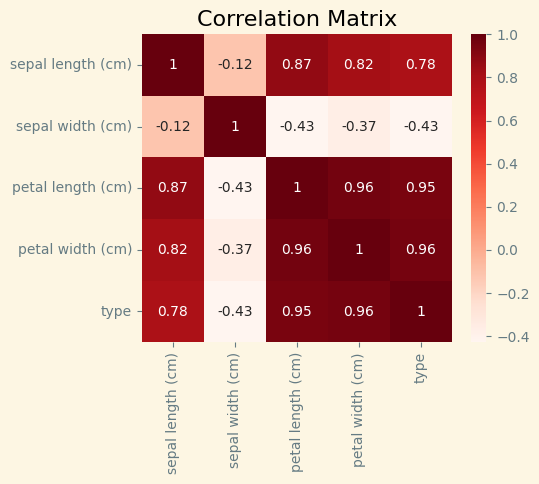

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(data=iris_df.corr(), cmap="Reds", annot=True, ax=ax)

plt.title("Correlation Matrix")
plt.show()

### histograms

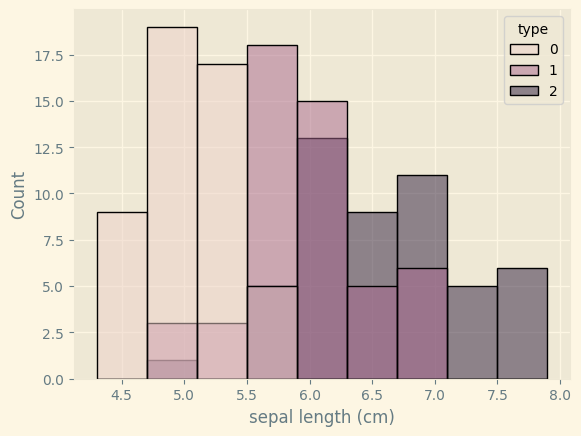

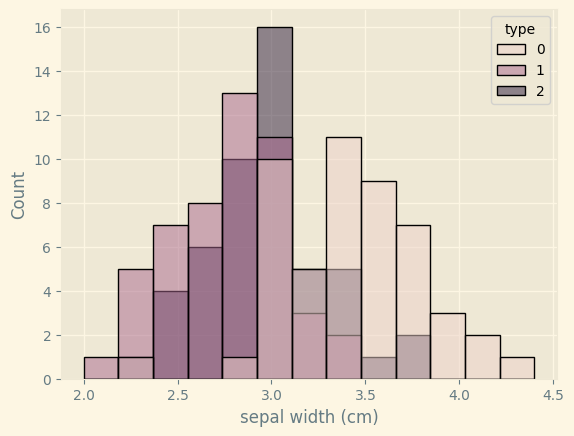

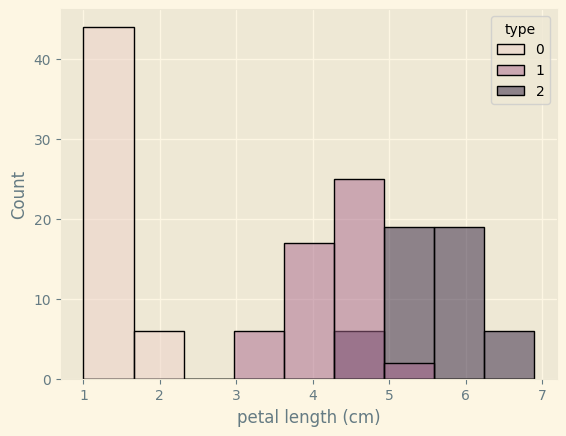

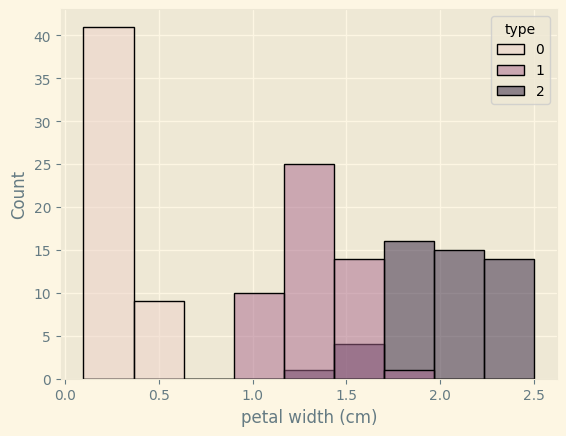

In [ ]:
for col in iris_X.columns:
    sns.histplot(data=iris_df, x=col, hue="type")
    plt.show()

### scatter plots

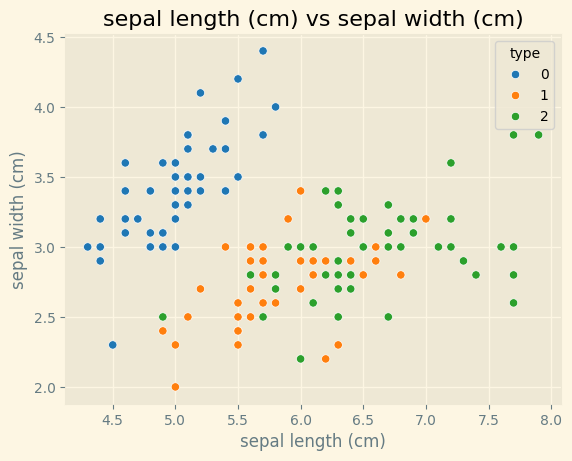

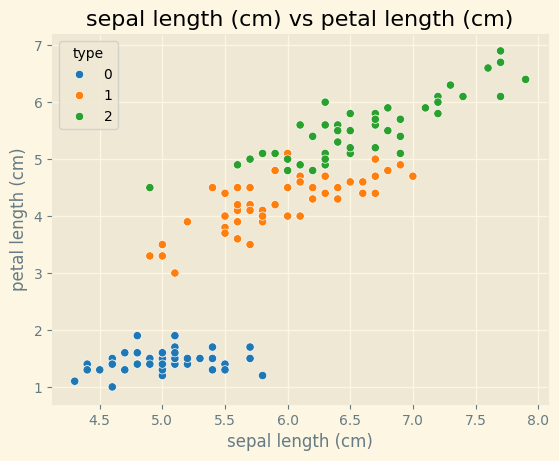

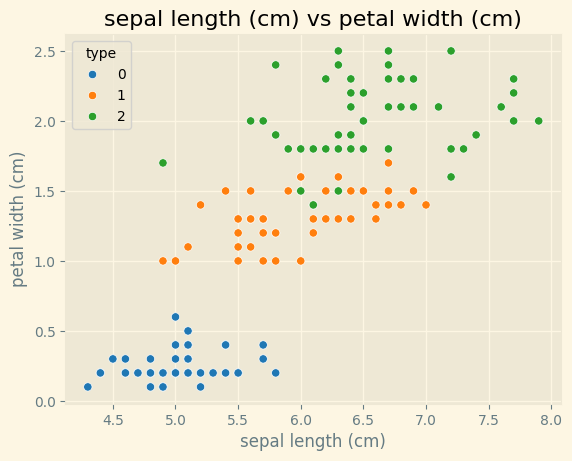

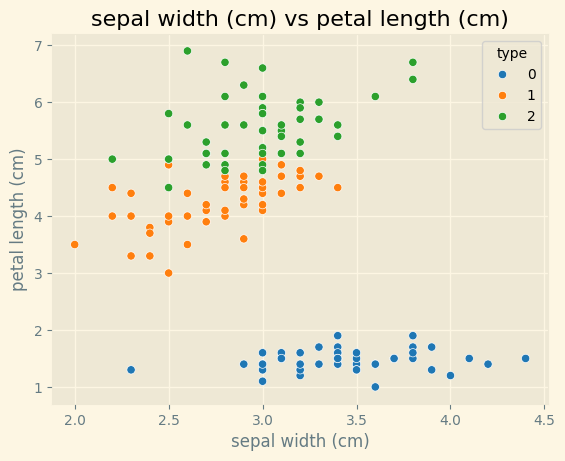

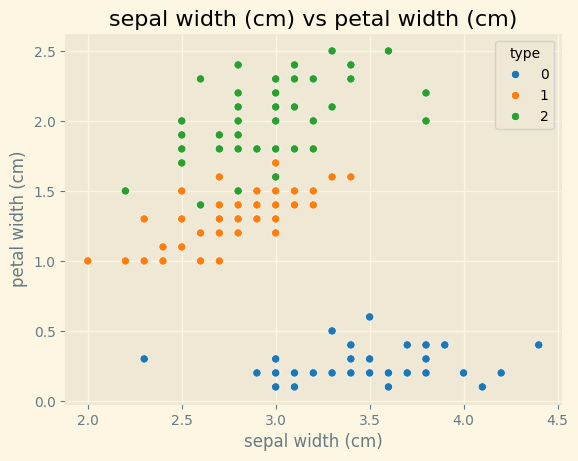

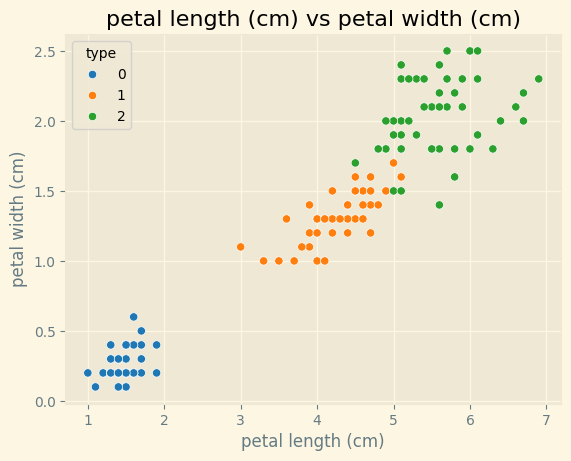

In [ ]:
cols_name = iris_X.columns
for i in range(len(cols_name)):
    for j in range(i + 1, len(cols_name)):
        sns.scatterplot(data=iris_df, x=cols_name[i], y=cols_name[j], hue="type", palette="tab10")

        plt.title(f"{cols_name[i]} vs {cols_name[j]}")
        plt.show()

## 2 Normalization

In [28]:
iris_norm = normalization(data=iris_X, model=MinMaxScaler().fit(iris_X))
iris_norm_min_max = normalization(data=iris_X, model=MinMaxScaler().fit(iris_X))

## 3 Apply ML Models

### K-Means
* normalized with StandardScaler
* in apply to all columns MinMaxScaler did better than StandardScaler
* in apply to selected columns results are same

#### function

In [29]:
def k_means(X_train, y_train, k, data):
    kmeans = KMeans(n_clusters=k, n_init='auto')
    y_pred_k_means = kmeans.fit_predict(X_train)

    y_pred_k_means_remapped = remap_clusters(y_train, y_pred_k_means)
    cm_k_means = confusion_matrix(y_train, y_pred_k_means_remapped)

    sns.heatmap(cm_k_means, annot=True, fmt='d', cmap='RdPu')
    plt.show()

    calculate_metrics(cm=cm_k_means)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4)) # dpi here

    plt.suptitle("K-Means Clustering", fontsize=10)

    sns.scatterplot(data=data, x="petal length (cm)", y="petal width (cm)", hue=y_train, ax=axes[0], palette="tab10", alpha=0.8)
    axes[0].set_title("Original y labels", fontsize=10)

    sns.scatterplot(data=data, x="petal length (cm)", y="petal width (cm)", hue=y_pred_k_means_remapped, ax=axes[1], palette="tab10", alpha=0.8)
    axes[1].set_title("Predicted y labels", fontsize=10)

    plt.show()

#### apply to all columns

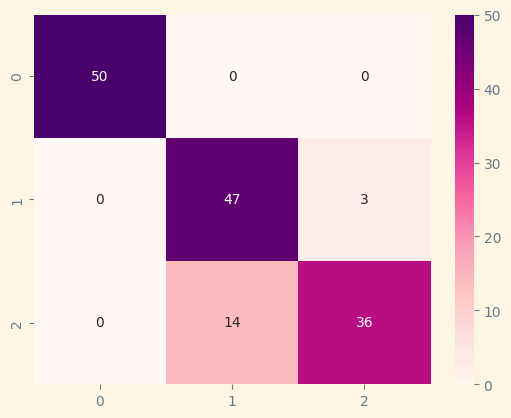

+----------+-----------+-------------+----------+------------+------------+
| Method   | Cluster   |   Precision |   Recall |   F1 Score | Accuracy   |
+==========+===========+=============+==========+============+============+
| K-Means  | 0         |       1     |    1     |      1     |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 1         |       0.77  |    0.94  |      0.85  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 2         |       0.92  |    0.72  |      0.81  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | Overall   |       0.898 |    0.887 |      0.885 | 88.67%     |
+----------+-----------+-------------+----------+------------+------------+


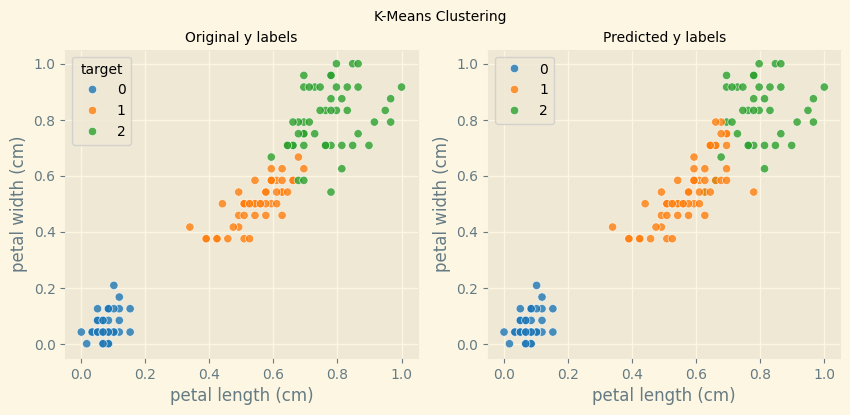

In [30]:
k_means(X_train=iris_norm_min_max, y_train=iris_y, k=3, data=iris_norm_min_max)

#### apply to selected columns

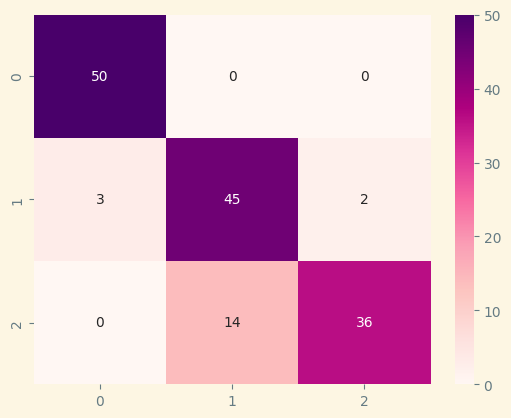

+----------+-----------+-------------+----------+------------+------------+
| Method   | Cluster   |   Precision |   Recall |   F1 Score | Accuracy   |
+==========+===========+=============+==========+============+============+
| K-Means  | 0         |       0.94  |    1     |      0.97  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 1         |       0.76  |    0.9   |      0.83  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 2         |       0.95  |    0.72  |      0.82  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | Overall   |       0.884 |    0.873 |      0.872 | 87.33%     |
+----------+-----------+-------------+----------+------------+------------+


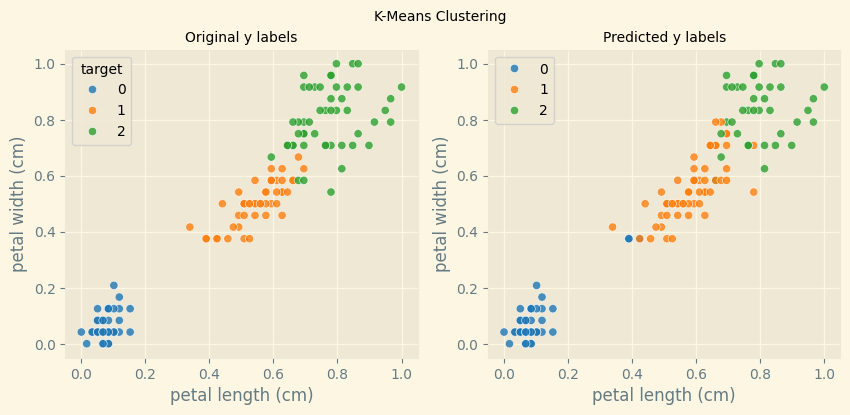

In [31]:
k_means(X_train=iris_norm.iloc[:, [0, 3]], y_train=iris_y, k=3, data=iris_norm)

### DB SCAN
* normalized with MinMaxScaler
* clustering is better with MinMaxScaler than StandardScaler
* finding the optimal eps is easier with MinMaxScaler

#### function

In [32]:
def db_scan(X_train, y_train, eps, min_sample, data):
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)
    y_pred_db_scan = dbscan.fit_predict(X_train)

    # remove noise
    mask = y_pred_db_scan != -1
    if np.sum(mask) == 0:
        print("All points were classified as noise. Try increasing eps or decreasing min_samples.")
        return

    # Raw cm
    cm_not_mapped = confusion_matrix(y_train, y_pred_db_scan)
    sns.heatmap(cm_not_mapped, annot=True, fmt='d', cmap='RdPu')
    plt.title("cm not mapped with noises")
    plt.show()

    X_train_no_noise = X_train[mask].copy()
    y_train_no_noise = y_train[mask].copy()
    y_pred_db_scan = y_pred_db_scan[mask]
    data_no_noise = data[mask].copy()

    y_pred_db_scan_remapped = remap_clusters(y_train_no_noise, y_pred_db_scan)
    cm_db_scan = confusion_matrix(y_train_no_noise, y_pred_db_scan_remapped)

    sns.heatmap(cm_db_scan, annot=True, fmt='d', cmap='RdPu')
    plt.show()

    calculate_metrics(cm=cm_db_scan)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    plt.suptitle("DBSCAN Clustering", fontsize=10)

    sns.scatterplot(data=data, x="petal length (cm)", y="petal width (cm)", hue=y_train, ax=axes[0], palette="tab10", alpha=0.8)
    axes[0].set_title("Original y labels", fontsize=10)

    sns.scatterplot(data=data_no_noise, x="petal length (cm)", y="petal width (cm)", hue=y_pred_db_scan_remapped, ax=axes[1], palette="tab10", alpha=0.8)
    axes[1].set_title("Predicted y labels", fontsize=10)

    plt.show()

#### apply to all columns

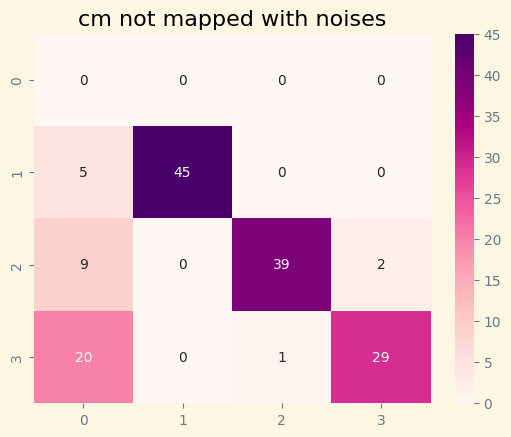

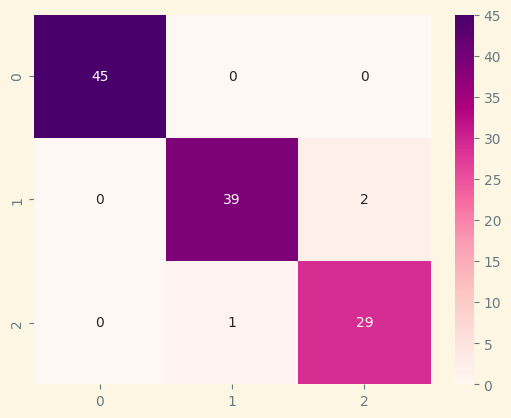

+----------+-----------+-------------+----------+------------+------------+
| Method   | Cluster   |   Precision |   Recall |   F1 Score | Accuracy   |
+==========+===========+=============+==========+============+============+
| K-Means  | 0         |       1     |    1     |      1     |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 1         |       0.97  |    0.95  |      0.96  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 2         |       0.94  |    0.97  |      0.95  |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | Overall   |       0.974 |    0.974 |      0.974 | 97.41%     |
+----------+-----------+-------------+----------+------------+------------+


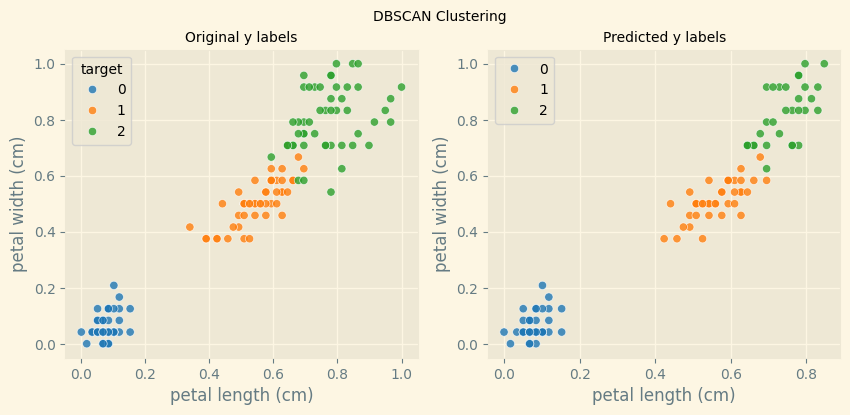

In [33]:
db_scan(X_train=iris_norm_min_max, y_train=iris_y, eps=0.128, min_sample=5, data=iris_norm_min_max)

#### apply to selected columns

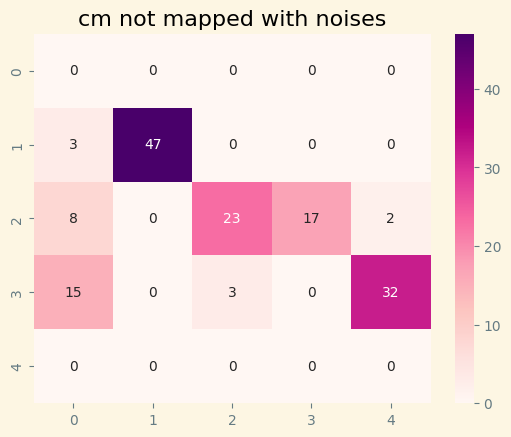

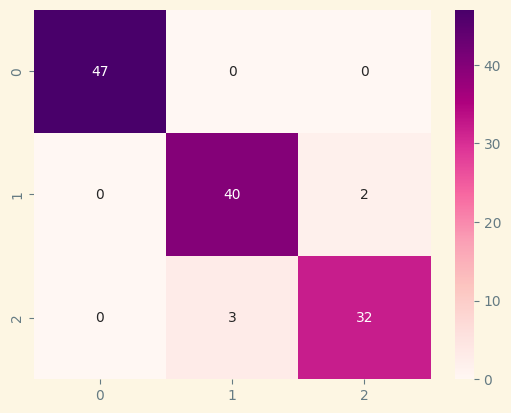

+----------+-----------+-------------+----------+------------+------------+
| Method   | Cluster   |   Precision |   Recall |   F1 Score | Accuracy   |
+==========+===========+=============+==========+============+============+
| K-Means  | 0         |        1    |     1    |       1    |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 1         |        0.93 |     0.95 |       0.94 |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | 2         |        0.94 |     0.91 |       0.93 |            |
+----------+-----------+-------------+----------+------------+------------+
| K-Means  | Overall   |        0.96 |     0.96 |       0.96 | 95.97%     |
+----------+-----------+-------------+----------+------------+------------+


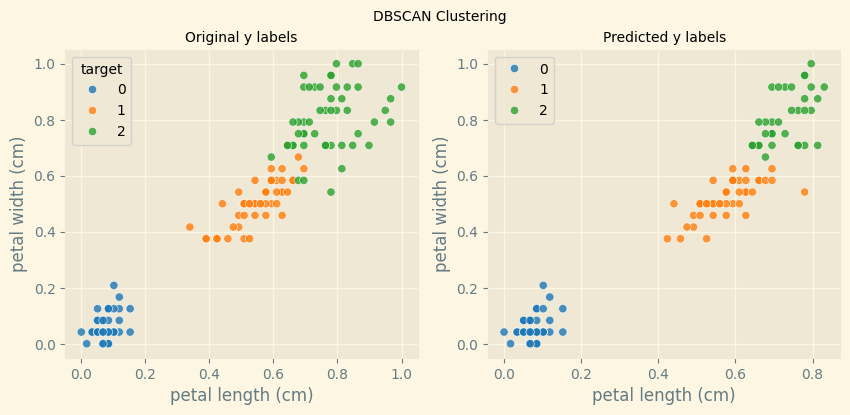

In [44]:
db_scan(X_train=iris_norm_min_max.iloc[:, [0, 3]], y_train=iris_y, eps=0.075, min_sample=5, data=iris_norm_min_max)

### KNN classification

In [35]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(iris_X, iris_y, test_size=0.33, random_state=42)

model_iris = StandardScaler().fit(X_train_iris)
X_train_iris = normalization(X_train_iris, model_iris)
X_test_iris = normalization(X_test_iris, model_iris)

In [36]:
knn_model_iris = KNeighborsClassifier(n_neighbors=5)
knn_model_iris.fit(X_train_iris, y_train_iris)

y_pred_knn_iris = knn_model_iris.predict(X_test_iris)

report = classification_report(y_true=y_test_iris, y_pred=y_pred_knn_iris)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



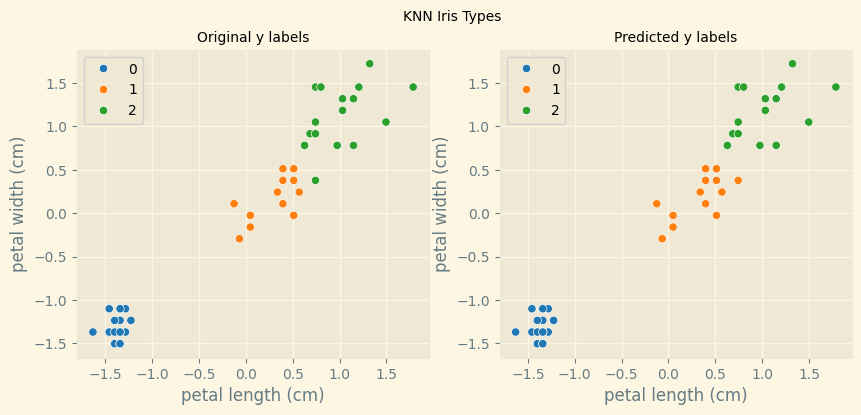

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plt.suptitle("KNN Iris Types", fontsize=10)

sns.scatterplot(data=X_test_iris, x="petal length (cm)", y="petal width (cm)", hue=np.array(y_test_iris), ax=axes[0], palette="tab10")
axes[0].set_title("Original y labels", fontsize=10)

sns.scatterplot(data=X_test_iris, x="petal length (cm)", y="petal width (cm)", hue=y_pred_knn_iris, ax=axes[1], palette="tab10")
axes[1].set_title("Predicted y labels", fontsize=10)

plt.show()